# F1 Wet Weather Strategy & Performance Analysis

This project analyses how wet-weather conditions influenced tyre strategy and driver performance across five Formula 1 races.

## Objectives

- Measure rainfall severity and duration
- Analyse intermediate tyre usage
- Compare tyre strategy with driver position changes
- Identify the largest position gains in wet races
- Prepare data for SQL analysis and Power BI visualisation

### Data Sources

- Driver and tyre strategy data: Excel dataset
- Weather data: Open-Meteo Historical Weather API
- Analysis: Python, SQL and Power BI

### Races Analysed

- 2019 German GP
- 2021 Emilia-Romagna GP
- 2023 Dutch GP
- 2023 Monaco GP
- 2024 British GP


In [2]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import sqlite3


In [13]:
df = pd.read_excel("Tyre Strat.xlsx")

df.head()



,Year,Race,Driver,Team,Grid Position,Finish Position,Position Change,Stint Number,Tyre,Start Lap,End Lap,Laps Used,Pit Stop After Stint
0,2019,German GP,Max Verstappen,Red Bull,2,1,1,1,WET,1,3,3,Yes
1,2019,German GP,Max Verstappen,Red Bull,2,1,1,2,INTERMEDIATE,4,25,22,Yes
2,2019,German GP,Max Verstappen,Red Bull,2,1,1,3,MEDIUM,26,29,4,Yes
3,2019,German GP,Max Verstappen,Red Bull,2,1,1,4,INTERMEDIATE,30,41,12,Yes
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,INTERMEDIATE,42,46,5,Yes


In [14]:
races = {
    "2019 German GP": ["2019-07-28", 49.327, 8.565, "Europe/Berlin"],
    "2021 Emilia-Romagna GP": ["2021-04-18", 44.3439, 11.7167, "Europe/Rome"],
    "2023 Dutch GP": ["2023-08-27", 52.3888, 4.5409, "Europe/Amsterdam"],
    "2023 Monaco GP": ["2023-05-28", 43.7347, 7.4206, "Europe/Monaco"],
    "2024 British GP": ["2024-07-07", 52.0733, -1.0147, "Europe/London"]
}

weather_results = []

for race, (date, lat, lon, timezone) in races.items():

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date,
        "end_date": date,
        "hourly": "rain",
        "timezone": timezone
    }

    response = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params=params
    )

    data = response.json()["hourly"]
    rain = pd.Series(data["rain"])

    weather_results.append({
        "Race": race,
        "Total_Rain": rain.sum(),
        "Max_Hourly_Rain": rain.max(),
        "Rain_Hours": (rain > 0).sum()
    })

weather_all = pd.DataFrame(weather_results)

weather_all


,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019 German GP,11.7,7.0,21
1,2021 Emilia-Romagna GP,0.7,0.2,5
2,2023 Dutch GP,3.4,0.7,12
3,2023 Monaco GP,6.9,4.3,9
4,2024 British GP,2.0,0.7,8


In [15]:
weather_summary = weather_all.copy()

weather_summary["Year"] = (
    weather_summary["Race"]
    .str.extract(r"^(\d{4})")
    .astype(int)
)

weather_summary["Race"] = (
    weather_summary["Race"]
    .str.replace(r"^\d{4}\s+", "", regex=True)
)

weather_summary = weather_summary[
    [
        "Year",
        "Race",
        "Total_Rain",
        "Max_Hourly_Rain",
        "Rain_Hours"
    ]
]

weather_summary


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019,German GP,11.7,7.0,21
1,2021,Emilia-Romagna GP,0.7,0.2,5
2,2023,Dutch GP,3.4,0.7,12
3,2023,Monaco GP,6.9,4.3,9
4,2024,British GP,2.0,0.7,8


In [17]:
df["Intermediate_Laps"] = np.where(
    df["Tyre"] == "INTERMEDIATE",
    df["Laps Used"],
    0
)

df["Tyre_Change"] = (
    df["Pit Stop After Stint"] == "Yes"
).astype(int)

strategy = (
    df.groupby(["Year", "Race", "Driver", "Team"])
    .agg(
        Grid_Position=("Grid Position", "first"),
        Finish_Position=("Finish Position", "first"),
        Position_Change=("Position Change", "first"),
        Tyre_Changes=("Tyre_Change", "sum"),
        Intermediate_Laps=("Intermediate_Laps", "sum"),
        Total_Laps=("Laps Used", "sum")
    )
    .reset_index()
)

strategy["Intermediate_Share"] = (
    strategy["Intermediate_Laps"] /
    strategy["Total_Laps"]
)

strategy.head()


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,Intermediate_Laps,Total_Laps,Intermediate_Share
0,2019,German GP,Carlos Sainz,McLaren,7,5,2,3,61,64,0.953125
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,39,64,0.609375
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,34,64,0.531250
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,43,64,0.671875
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,39,64,0.609375


In [18]:
strategy = strategy.merge(
    weather_summary,
    on=["Year", "Race"],
    how="left"
)

strategy.head()


,Year,Race,Driver,Team,Grid_Position,Finish_Position,Position_Change,Tyre_Changes,Intermediate_Laps,Total_Laps,Intermediate_Share,Total_Rain,Max_Hourly_Rain,Rain_Hours
0,2019,German GP,Carlos Sainz,McLaren,7,5,2,3,61,64,0.953125,11.7,7.0,21
1,2019,German GP,Daniil Kvyat,Toro Rosso,14,3,11,4,39,64,0.609375,11.7,7.0,21
2,2019,German GP,Lance Stroll,Racing Point,15,4,11,5,34,64,0.531250,11.7,7.0,21
3,2019,German GP,Lewis Hamilton,Mercedes,1,9,-8,6,43,64,0.671875,11.7,7.0,21
4,2019,German GP,Max Verstappen,Red Bull,2,1,1,5,39,64,0.609375,11.7,7.0,21


In [19]:
correlations = strategy[
    [
        "Total_Rain",
        "Rain_Hours",
        "Intermediate_Share",
        "Tyre_Changes",
        "Position_Change"
    ]
].corr()

correlations


,Total_Rain,Rain_Hours,Intermediate_Share,Tyre_Changes,Position_Change
Total_Rain,1.000000,0.888194,0.674746,0.275447,0.321480
Rain_Hours,0.888194,1.000000,0.680728,0.588032,0.374930
Intermediate_Share,0.674746,0.680728,1.000000,0.269045,0.287293
Tyre_Changes,0.275447,0.588032,0.269045,1.000000,0.185378
Position_Change,0.321480,0.374930,0.287293,0.185378,1.000000


In [20]:
correlations["Position_Change"].sort_values(ascending=False)


,Position_Change
Position_Change,1.000000
Rain_Hours,0.374930
Total_Rain,0.321480
Intermediate_Share,0.287293
Tyre_Changes,0.185378


In [21]:
race_summary = (
    strategy
    .groupby(["Year", "Race"])
    .agg(
        Total_Rain=("Total_Rain", "first"),
        Max_Hourly_Rain=("Max_Hourly_Rain", "first"),
        Rain_Hours=("Rain_Hours", "first"),
        Avg_Position_Change=("Position_Change", "mean"),
        Avg_Intermediate_Share=("Intermediate_Share", "mean"),
        Avg_Tyre_Changes=("Tyre_Changes", "mean"),
        Max_Position_Gain=("Position_Change", "max")
    )
    .reset_index()
)

race_summary


,Year,Race,Total_Rain,Max_Hourly_Rain,Rain_Hours,Avg_Position_Change,Avg_Intermediate_Share,Avg_Tyre_Changes,Max_Position_Gain
0,2019,German GP,11.7,7.0,21,5.833333,0.666667,4.666667,18
1,2021,Emilia-Romagna GP,0.7,0.2,5,1.333333,0.394180,2.833333,4
2,2023,Dutch GP,3.4,0.7,12,2.000000,0.263889,5.166667,9
3,2023,Monaco GP,6.9,4.3,9,0.833333,0.301920,1.666667,3
4,2024,British GP,2.0,0.7,8,0.833333,0.227564,2.166667,2


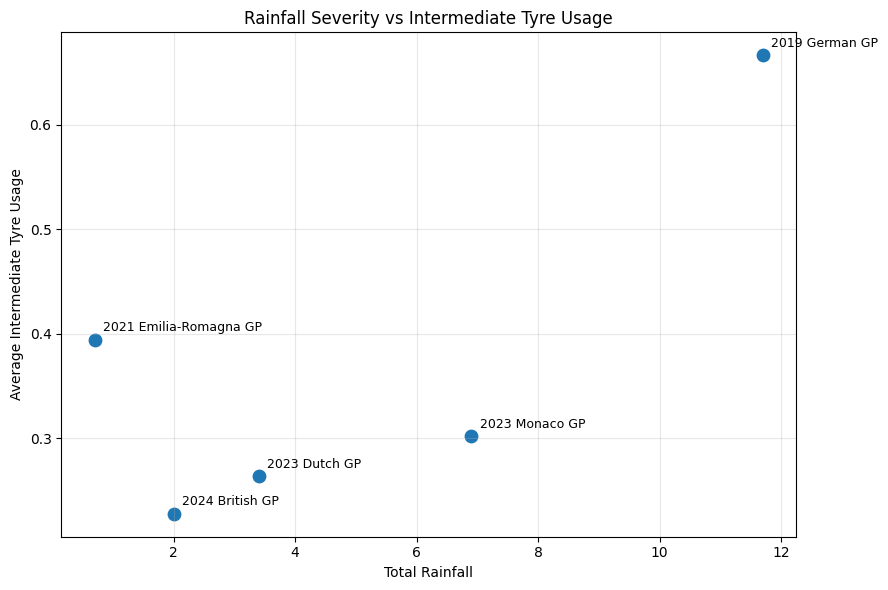

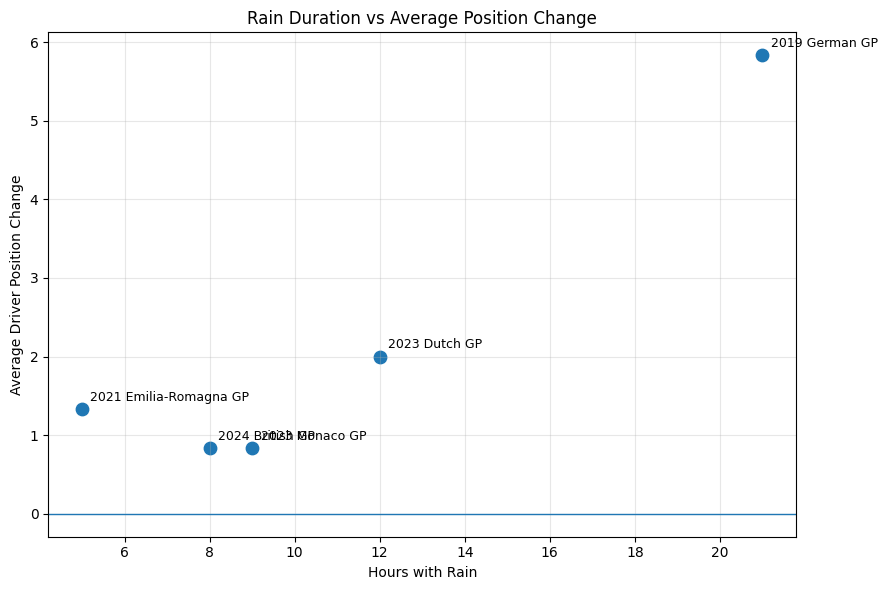

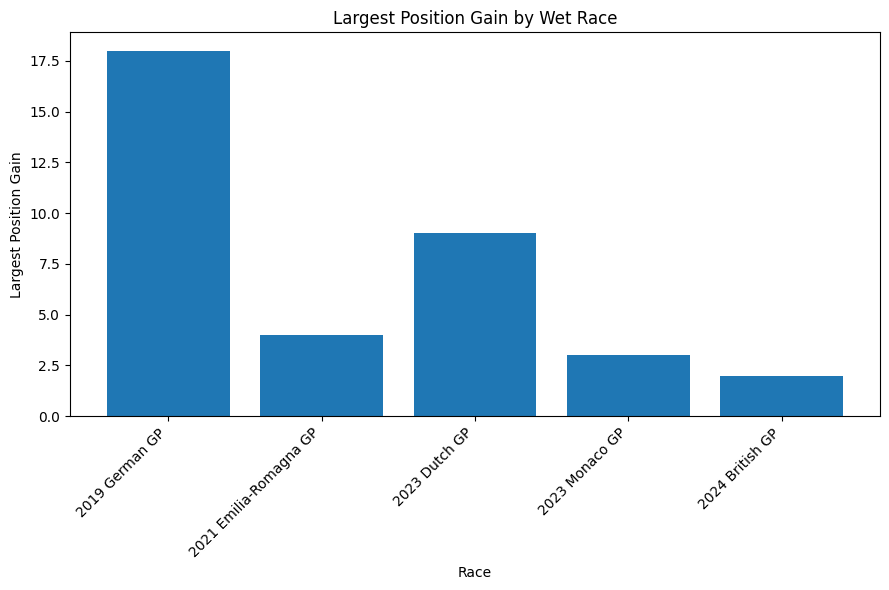

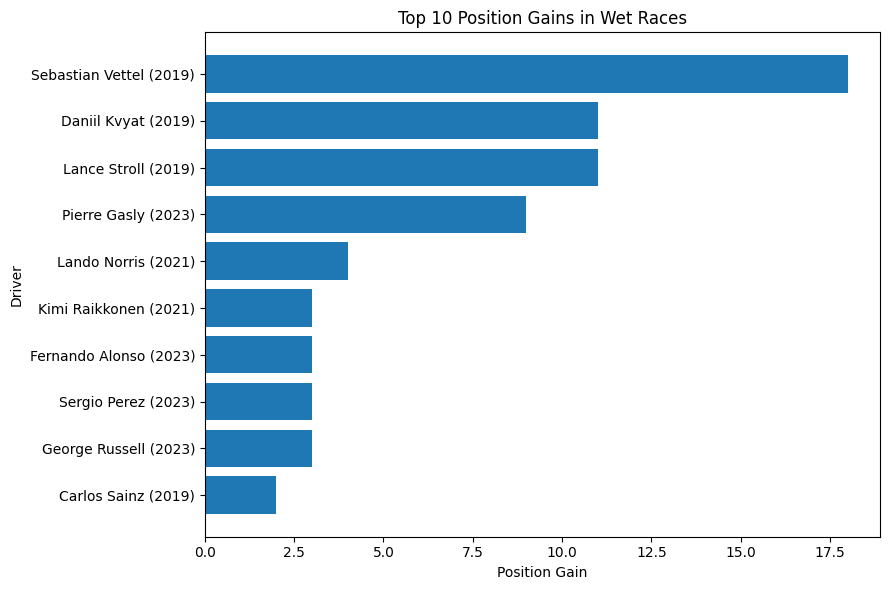

In [26]:
import matplotlib.pyplot as plt

# ============================================================
# 1. Rainfall Severity vs Intermediate Tyre Usage
# ============================================================

race_summary = strategy.groupby(["Year", "Race"]).agg(
    Intermediate_Share=("Intermediate_Share", "mean")
).reset_index()

race_summary = race_summary.merge(
    weather_summary,
    on=["Year", "Race"],
    how="left"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    race_summary["Total_Rain"],
    race_summary["Intermediate_Share"],
    s=80
)

for _, row in race_summary.iterrows():
    plt.annotate(
        f"{row['Year']} {row['Race']}",
        (row["Total_Rain"], row["Intermediate_Share"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Total Rainfall")
plt.ylabel("Average Intermediate Tyre Usage")
plt.title("Rainfall Severity vs Intermediate Tyre Usage")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("rainfall_vs_strategy.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 2. Rain Duration vs Average Position Change
# ============================================================

position_summary = strategy.groupby(["Year", "Race"]).agg(
    Average_Position_Change=("Position_Change", "mean")
).reset_index()

position_summary = position_summary.merge(
    weather_summary,
    on=["Year", "Race"],
    how="left"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    position_summary["Rain_Hours"],
    position_summary["Average_Position_Change"],
    s=80
)

for _, row in position_summary.iterrows():
    plt.annotate(
        f"{row['Year']} {row['Race']}",
        (row["Rain_Hours"], row["Average_Position_Change"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Hours with Rain")
plt.ylabel("Average Driver Position Change")
plt.title("Rain Duration vs Average Position Change")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("rainfall_vs_position_change.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 3. Largest Position Gain by Race
# ============================================================

race_gains = (
    strategy.groupby(["Year", "Race"])["Position_Change"]
    .max()
    .reset_index()
)

race_gains["Race_Label"] = (
    race_gains["Year"].astype(str)
    + " "
    + race_gains["Race"]
)

plt.figure(figsize=(9, 6))

plt.bar(
    race_gains["Race_Label"],
    race_gains["Position_Change"]
)

plt.xlabel("Race")
plt.ylabel("Largest Position Gain")
plt.title("Largest Position Gain by Wet Race")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("position_gains.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 4. Top 10 Driver Position Gains
# ============================================================

top_gains = strategy.nlargest(10, "Position_Change").copy()

top_gains["Driver_Race"] = (
    top_gains["Driver"]
    + " ("
    + top_gains["Year"].astype(str)
    + ")"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_gains["Driver_Race"],
    top_gains["Position_Change"]
)

plt.xlabel("Position Gain")
plt.ylabel("Driver")
plt.title("Top 10 Position Gains in Wet Races")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("top_driver_gains.png", dpi=300, bbox_inches="tight")
plt.show()


In [23]:
races_sql = weather_summary.copy()

strategy_sql = strategy[
    [
        "Year",
        "Race",
        "Driver",
        "Team",
        "Grid_Position",
        "Finish_Position",
        "Position_Change",
        "Tyre_Changes",
        "Intermediate_Laps",
        "Total_Laps",
        "Intermediate_Share"
    ]
].copy()

conn = sqlite3.connect("f1_wet_weather.db")

races_sql.to_sql(
    "races",
    conn,
    if_exists="replace",
    index=False
)

strategy_sql.to_sql(
    "race_strategy",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")


Database created successfully.


In [24]:
query = """
SELECT
    rs.Driver,
    rs.Race,
    r.Total_Rain,
    r.Rain_Hours,
    rs.Intermediate_Share,
    rs.Tyre_Changes,
    rs.Position_Change
FROM race_strategy rs
JOIN races r
    ON rs.Year = r.Year
    AND rs.Race = r.Race
ORDER BY rs.Position_Change DESC
LIMIT 10;
"""

top_driver_results = pd.read_sql_query(
    query,
    conn
)

top_driver_results


,Driver,Race,Total_Rain,Rain_Hours,Intermediate_Share,Tyre_Changes,Position_Change
0,Sebastian Vettel,German GP,11.7,21,0.625000,5,18
1,Daniil Kvyat,German GP,11.7,21,0.609375,4,11
2,Lance Stroll,German GP,11.7,21,0.531250,5,11
3,Pierre Gasly,Dutch GP,3.4,12,0.305556,5,9
4,Lando Norris,Emilia-Romagna GP,0.7,5,0.444444,2,4
5,Kimi Raikkonen,Emilia-Romagna GP,0.7,5,0.412698,3,3
6,Fernando Alonso,Dutch GP,3.4,12,0.263889,5,3
7,Sergio Perez,Dutch GP,3.4,12,0.319444,6,3
8,George Russell,Monaco GP,6.9,9,0.307692,1,3
9,Carlos Sainz,German GP,11.7,21,0.953125,3,2


In [25]:
races_sql.to_csv(
    "races_powerbi.csv",
    index=False
)

strategy_sql.to_csv(
    "strategy_powerbi.csv",
    index=False
)

conn.close()

print("Power BI files exported.")


Power BI files exported.
